<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Dry_Spell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap as gee
import xarray as xr


In [2]:
!pip install xee
import xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00


In [3]:
ee.Authenticate()
ee.Initialize(project = 'ee-abirnahraf', opt_url = 'https://earthengine-highvolume.googleapis.com')

In [4]:
map = gee.Map(basemap = 'ROADMAP')
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [5]:
roi = map.draw_last_feature.geometry()

In [25]:
collection = ee.ImageCollection("NOAA/PERSIANN-CDR").filterDate('2015','2024')

In [26]:
ds = xr.open_dataset(collection, engine = 'ee', crs = 'EPSG:4326', geometry = roi, scale = 0.27)

ds

<xarray.Dataset> Size: 289kB
Dimensions:        (time: 3286, lon: 4, lat: 5)
Coordinates:
  * time           (time) datetime64[ns] 26kB 2015-01-01 ... 2023-12-31
  * lon            (lon) float64 32B 88.86 89.13 89.4 89.67
  * lat            (lat) float64 40B 23.19 23.46 23.73 24.0 24.27
Data variables:
    precipitation  (time, lon, lat) float32 263kB ...
Attributes: (12/20)
    date_range:               [410227200000, 1625011200000]
    description:              <p>PERSIANN-CDR is a daily quasi-global precipi...
    keywords:                 ['cdr', 'climate', 'geophysical', 'ncdc', 'noaa...
    period:                   1
    period_mapping:           [410227200000, 1625011200000]
    product_tags:             ['precipitation', 'persiann', 'geophysical', 'w...
    ...                       ...
    visualization_0_bands:    precipitation
    visualization_0_max:      50.0
    visualization_0_min:      0.0
    visualization_0_name:     Precipitation
    visualization_0_palette:  3907ff,03fff3,28ff25,fbff09,ff1105
    crs:                      EPSG:4326

**calculate the total precipitation for each quarter of the year**

In [27]:
seasonal = ds.resample(time = 'Q').sum('time')


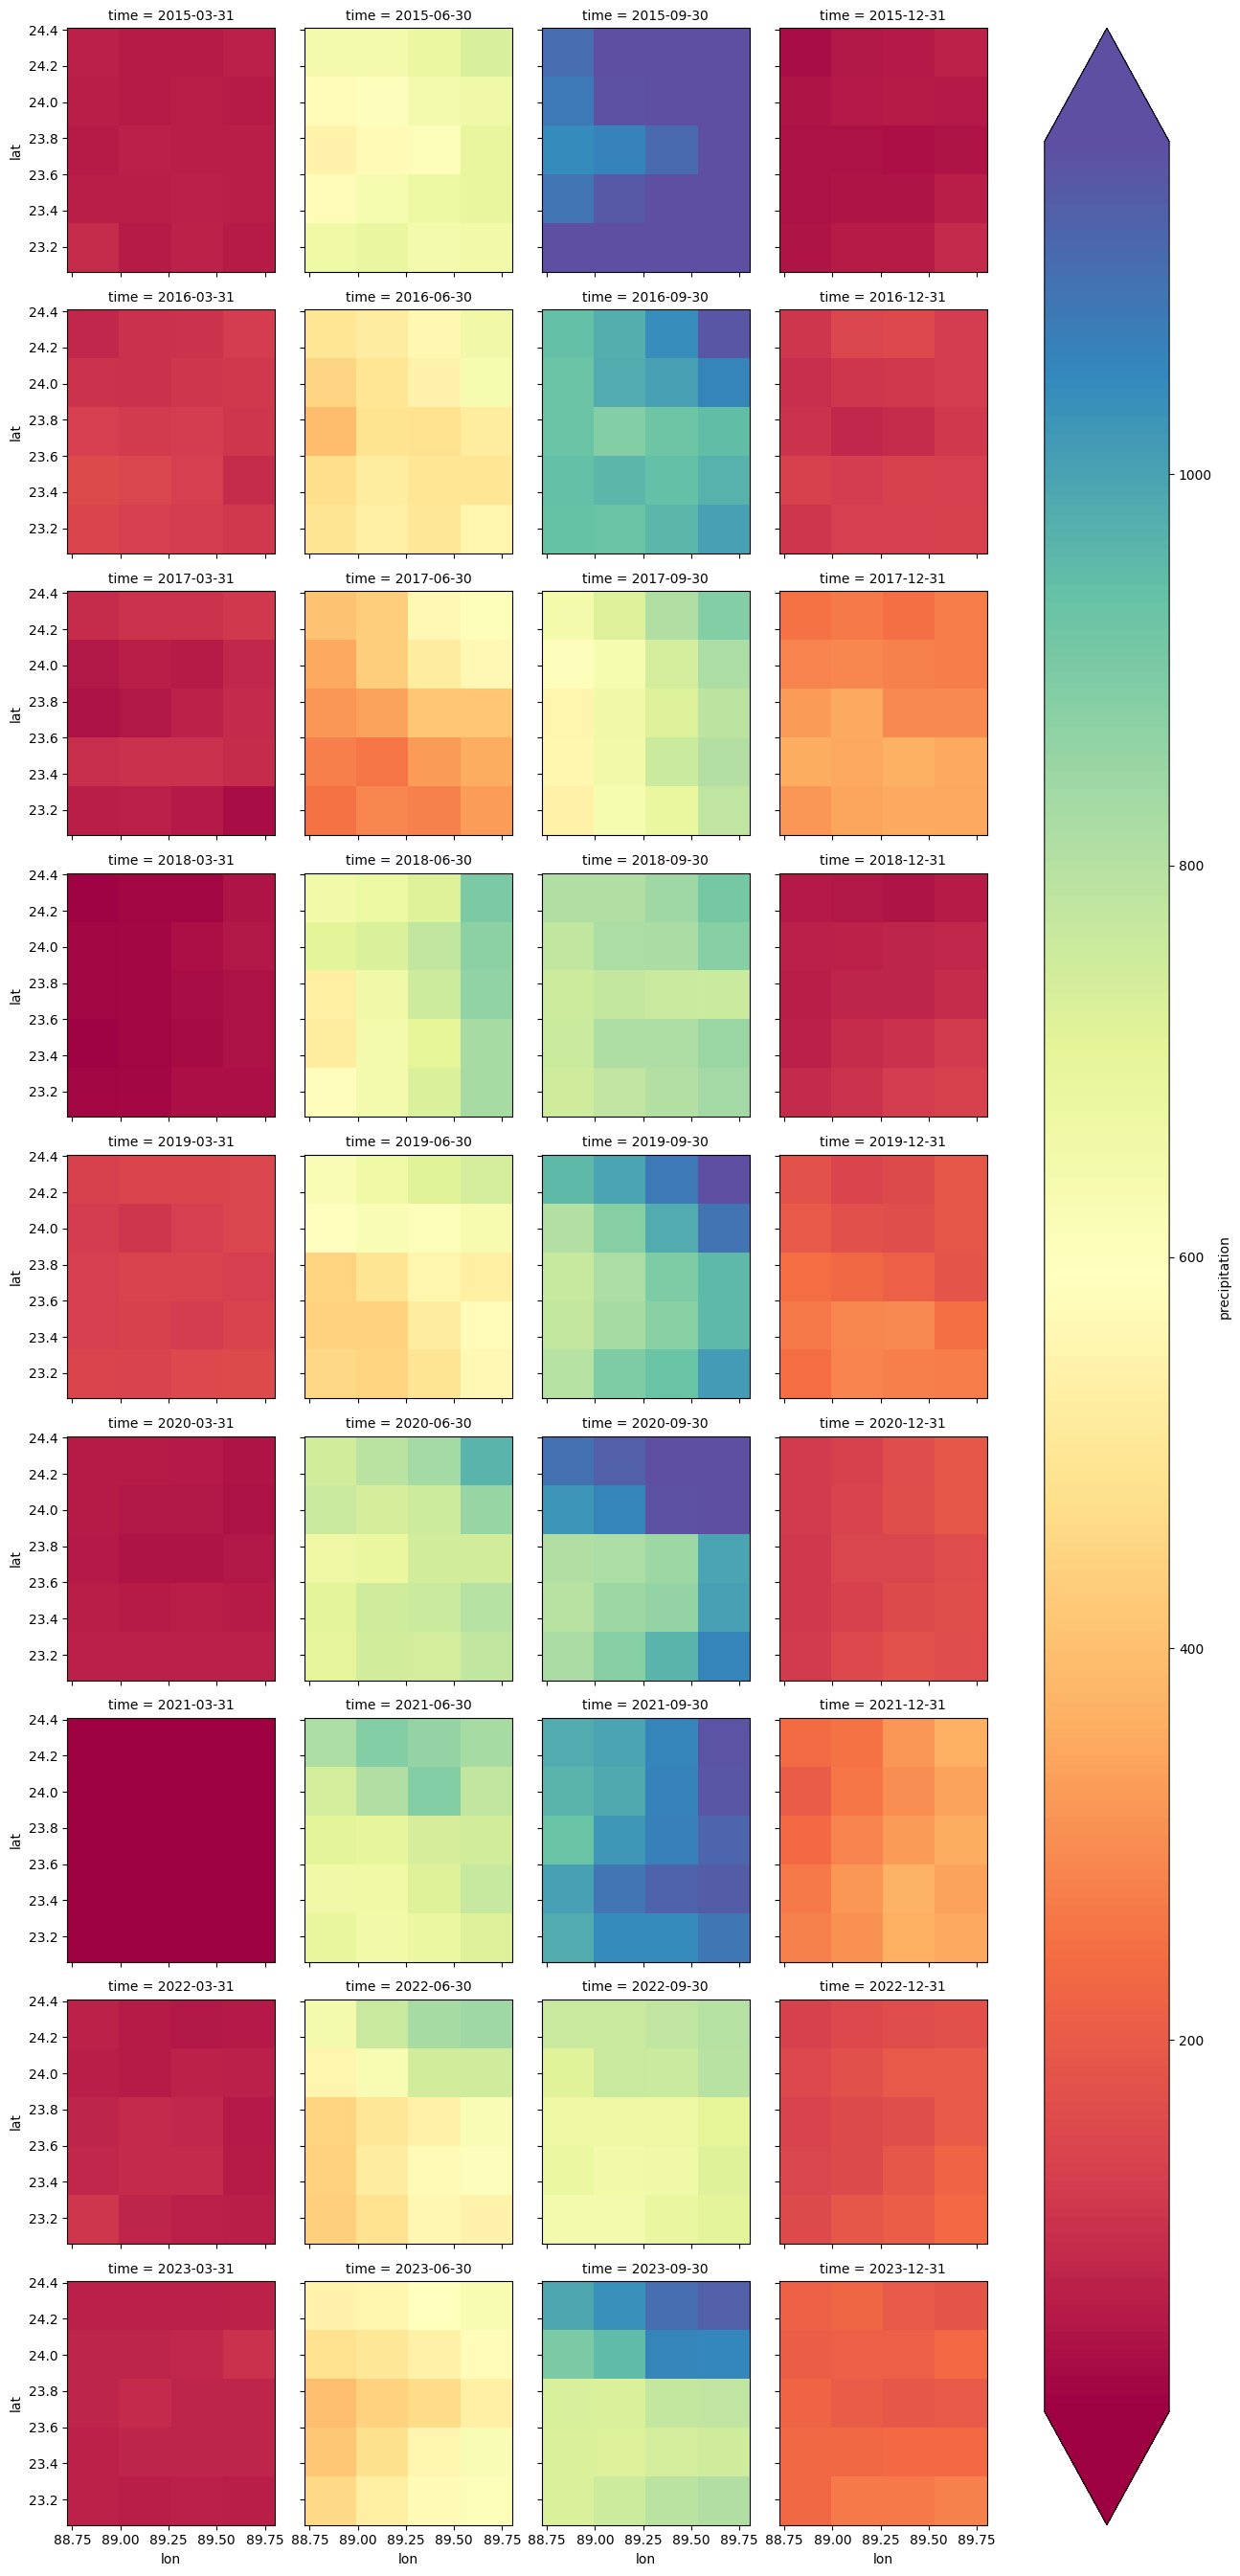

In [28]:
seasonal.precipitation.plot(x = 'lon', y = 'lat', col = 'time', robust = True, col_wrap = 4, cmap = 'Spectral')


In [29]:
point = ds.sel(lon = 52.6632665918151, lat = 36.54071077336493, method = 'nearest')


In [30]:
pr = point.precipitation.values
time =point.time.values

### extract the actual numerical data and time values

In [31]:
import pandas as pd

In [32]:
df = pd.DataFrame({'time': time, 'pr': pr})

**creates a new column in the DataFrame**

In [33]:
df['dry'] = df['pr'] == 0

**creates a new column that assigns a unique number to consecutive periods**

In [34]:
df['group'] = (df['dry'] != df['dry'].shift()).cumsum()

**calculates the characteristics of each dry spell**

In [40]:
dry_spell = df[df['dry']].groupby('group').agg(
    start_date = ('time', 'first'),
    end_date = ('time', 'last'),
    duration = ('time', 'count'),
    intensity = ('pr', 'sum')
)

**DataFrame and display only the rows where the 'duration' of the dry spell is greater than 15 days.**

In [41]:
dry_spell[dry_spell['duration'] > 15]

,start_date,end_date,duration,intensity
group,,,,
4,2015-01-14,2015-02-05,23,0.0
18,2015-03-10,2015-03-26,17,0.0
76,2015-11-18,2015-12-07,20,0.0
78,2015-12-09,2015-12-29,21,0.0
82,2016-01-14,2016-02-06,24,0.0
146,2016-12-02,2017-01-09,39,0.0
150,2017-01-28,2017-03-02,34,0.0
218,2017-11-18,2017-12-06,19,0.0
222,2017-12-20,2018-02-06,49,0.0


In [37]:
result = dry_spell[dry_spell['duration'] > 10]

In [38]:
result.to_csv('dry_spell.csv')

In [39]:
from google.colab import files

files.download('dry_spell.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>